# GTEx


In [9]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd

import importlib
import functions
import auxillary_plots
import constants
importlib.reload(constants)
importlib.reload(auxillary_plots)
importlib.reload(functions)
from constants import *

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.2e}" if abs(x) < 0.01 else f"{x:.3f}"
)

print(f'Specificity metric: {SPECIFICITY_METRIC}')
print(f'Specificity threshold: {SPECIFICITY_THR}')
print(f'Figure mode: {FIG_MODE}')

print("PROJ_ROOT:", PROJ_ROOT)


Specificity metric: Tau
Specificity threshold: 0.8
Figure mode: pdf
PROJ_ROOT: /Users/neuropromotion/Desktop/miRNA/bulk_review


In [2]:
gtex_loader = functions.Load_GTEx_Data(PATH_GTEX_COUNTS, PATH_GTEX_META)

In [3]:
lin_df, specificity_gtex_df = gtex_loader.run_pipeline()

Running Tau score, per SMTSD, log2(CPM+1) [log_of_mean]...


In [4]:
cpm = gtex_loader.CPM(log=True)
specificity_gtex_df["gtex_tissues"] = specificity_gtex_df.apply(
    lambda row: functions.get_top_tissues_expression(row, cpm, threshold=0),
    axis=1,
)

In [5]:
specificity_gtex_df

,mature_name,Tau_gtex,gtex_tissues
0,hsa-mir-302a-3p,0.981,"Heart [0.67], Brain [0.13], Soft Tissues [0.03]"
1,hsa-mir-302b-3p,0.980,"Heart [0.67], Brain [0.18], Soft Tissues [0.06]"
2,hsa-mir-302a-5p,0.978,"Heart [0.64], Brain [0.10], Testis [0.06]"
3,hsa-mir-302d-3p,0.978,"Heart [0.64], Brain [0.11], Soft Tissues [0.05]"
4,hsa-mir-486-5p,0.974,"Whole Blood [0.61], Fallopian Tube [0.31], Lun..."
...,...,...,...
389,hsa-mir-27b-3p,0.088,"Mucosa [0.04], Heart [0.04], Kidney [0.04]"
390,hsa-let-7b-5p,0.087,"Skin [0.04], Omentum [0.04], Breast [0.04]"
391,hsa-mir-100-5p,0.080,"Thyroid [0.04], Ovary [0.04], Fallopian Tube [..."
392,hsa-mir-24-3p,0.078,"Heart [0.04], Skin [0.04], Lung [0.04]"


In [6]:
specificity_gtex_df.to_csv(TAB_OUT / f'{SPECIFICITY_METRIC}_gtex.csv')

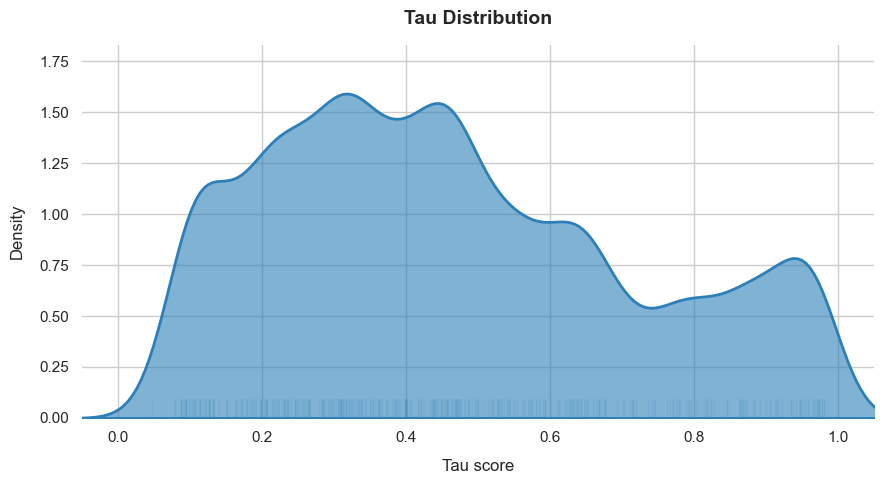

In [7]:
auxillary_plots.plot_specificity_distribution(specificity_gtex_df, 
                    f'{SPECIFICITY_METRIC}_gtex', 
                    save_path= FIG_OUT / f'{SPECIFICITY_METRIC}_distributions_GTEX.{FIG_MODE}')

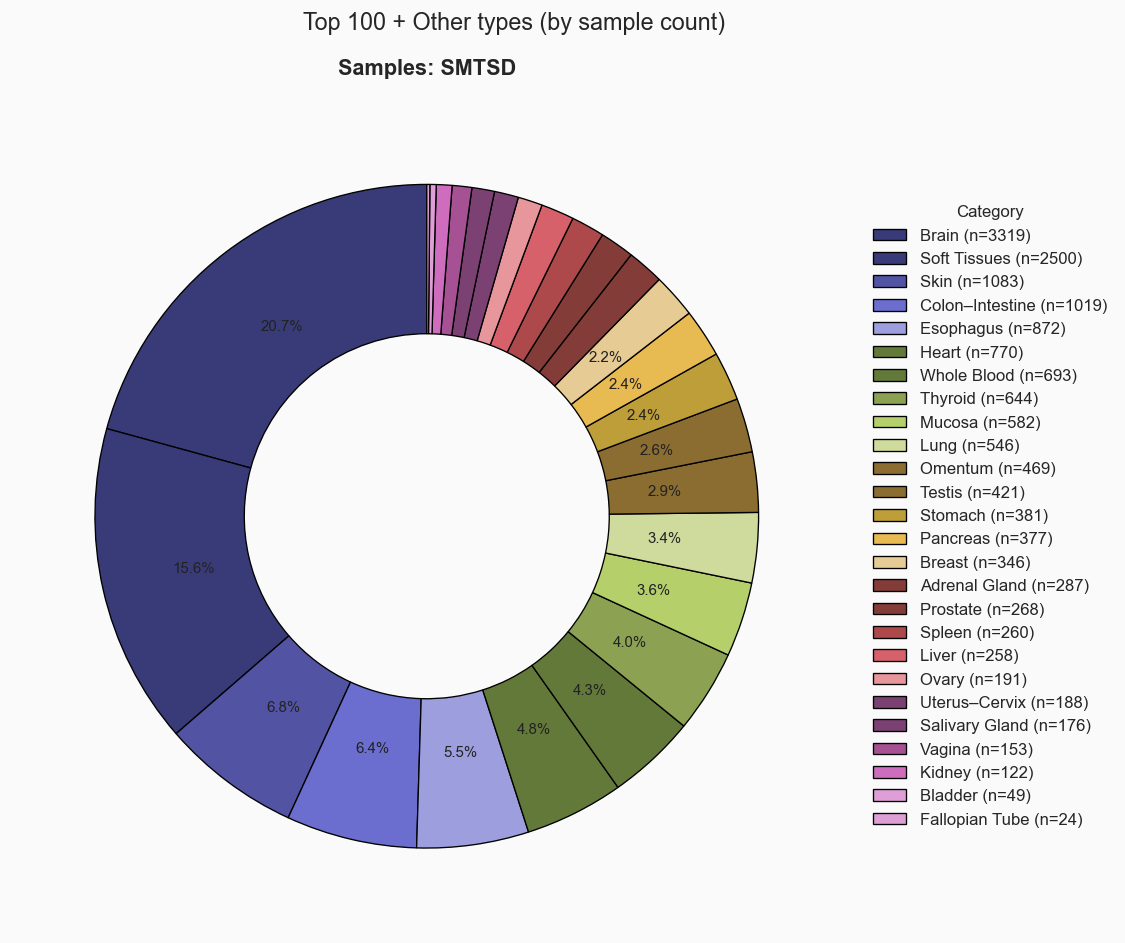

In [8]:
gtex_loader.plot_pie(save_path = FIG_OUT / f'gtex_pie.{FIG_MODE}')